# Training

## 1. Load data

In [31]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

from analyse.analyse import (evaluer_auc, importance_permutation, tableau_tranches, tracer_importances)
from cible import (VARIABLES_MODELE, ajouter_eloignee, ajuster_modele_decision, cible_individuelle,
                   coefficients, entrainer_modele_cible, score_merite)

In [32]:
def ajouter_attributs(df, reference):
    """Ajoute la cote R relative a la region et au revenu (medianes calculees sur `reference`).

    - cote_r_rel_a_region : cote R / mediane de la cote R dans la region du dossier ;
    - cote_r_rel_au_revenu : cote R / mediane de la cote R dans la tranche de revenu du dossier
      (15 tranches de meme effectif dans `reference`).
    Les medianes et les bornes viennent de `reference` : les candidats sont mesures avec la meme
    definition que l'historique.
    """
    mediane_region = reference.groupby('region_administrative')['cote_r_equivalent'].median()
    _, bornes = pd.qcut(reference['revenu_familial_estime'], q=15, retbins=True)
    bornes[0], bornes[-1] = -np.inf, np.inf
    tranche = lambda d: pd.cut(d['revenu_familial_estime'], bornes, labels=False)
    mediane_revenu = reference['cote_r_equivalent'].groupby(tranche(reference)).median()

    df.insert(0, 'cote_r_rel_au_revenu', df['cote_r_equivalent'] / tranche(df).map(mediane_revenu))
    df.insert(0, 'cote_r_rel_a_region',
              df['cote_r_equivalent'] / df['region_administrative'].map(mediane_region))


demandes = pd.read_csv('data/donnees_demandes.csv')
groupe_hist = np.where(ajouter_eloignee(demandes)['eloignee'] == 1, 'Eloignee', 'Centre')
ajouter_attributs(demandes, reference=demandes.copy())
print(f'{len(demandes)} dossiers historiques')

10000 dossiers historiques


In [33]:
demandes.info()
print()
print(demandes.describe(include='all').T[['count', 'unique', 'top', 'mean']])

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   cote_r_rel_a_region                10000 non-null  float64
 1   cote_r_rel_au_revenu               10000 non-null  float64
 2   id_candidat                        10000 non-null  str    
 3   cote_r_equivalent                  10000 non-null  float64
 4   programme_etudes                   10000 non-null  str    
 5   region_administrative              10000 non-null  str    
 6   code_postal_3                      10000 non-null  str    
 7   revenu_familial_estime             10000 non-null  int64  
 8   heures_travail_semaine             10000 non-null  int64  
 9   distance_domicile_campus_km        10000 non-null  float64
 10  premiere_generation_universitaire  10000 non-null  int64  
 11  decision_octroi                    10000 non-null  int64  
dtypes:

In [34]:
# La cible n'est pas decision_octroi, biaisee, mais la cible individuelle (cible.cible_individuelle).
# Elle se construit a partir d'un modele de decision du comite (regression logistique avec la region) :
# - evaluation : modele de decision ajuste sur train seulement (cellule 12), pour eviter toute fuite ;
# - modele final : modele de decision ajuste sur tout l'historique (section Prediction).
# decision_octroi et la region restent donc dans `demandes` : elles servent a construire la cible.
print('Taux d\'octroi du comite par groupe :',
      demandes['decision_octroi'].groupby(groupe_hist).mean().round(3).to_dict())

Taux d'octroi du comite par groupe : {'Centre': 0.484, 'Eloignee': 0.273}


## 2. Prepare features

In [35]:
# Variables du modele : celles de cible.VARIABLES_MODELE (ni la region ni le code postal, ni la distance
# ni le revenu, dont la cible a retire l'effet), plus la cote R relative a la region et au revenu.
NOUVELLES_VARIABLES = ['cote_r_rel_a_region', 'cote_r_rel_au_revenu']
VARIABLES = VARIABLES_MODELE + NOUVELLES_VARIABLES
CATEGORIELLES = ['programme_etudes']
print('Variables du modele :', VARIABLES)

Variables du modele : ['cote_r_equivalent', 'heures_travail_semaine', 'premiere_generation_universitaire', 'programme_etudes', 'cote_r_rel_a_region', 'cote_r_rel_au_revenu']


In [36]:
for col in VARIABLES + ['decision_octroi', 'region_administrative']:
    if col not in demandes.columns:
        raise ValueError(f"Colonne {col} manquante dans les données d'entrée.")

In [37]:
# Meme decoupage que la baseline et model_corrige.ipynb (stratifie sur la decision du comite).
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)

In [38]:
def preparer(df):
    """Variables du modele, dans l'ordre attendu par le pipeline."""
    return df[VARIABLES]

In [39]:
TAUX_MIN, TAUX_MAX = 0.36, 0.44   # budget : taux d'octroi exige sur les candidats
MARGE = 0.01                       # le seuil est cherche a l'interieur du budget : le taux varie d'un jeu a l'autre


def exactitude_attendue(cible, decisions):
    """Exactitude moyenne contre une cible souple : un octroi vaut cible, un refus vaut 1 - cible."""
    cible, decisions = np.asarray(cible), np.asarray(decisions)
    return np.mean(decisions * cible + (1 - decisions) * (1 - cible))


def choisir_seuil(proba, cible, taux_min=TAUX_MIN + MARGE, taux_max=TAUX_MAX - MARGE,
                  critere=exactitude_attendue):
    """Seuil de probabilite qui maximise `critere`, parmi ceux dont le taux d'octroi est dans [taux_min, taux_max].

    Les seuils candidats sont les quantiles de `proba` correspondant a ces taux.
    Retourne (seuil, taux d'octroi obtenu).
    """
    proba = np.asarray(proba)
    seuils = np.unique(np.quantile(proba, np.linspace(1 - taux_max, 1 - taux_min, 161)))
    scores = [critere(cible, (proba >= s).astype(int)) for s in seuils]
    meilleur = seuils[int(np.argmax(scores))]
    return meilleur, np.mean(proba >= meilleur)


def appliquer_seuil(proba, seuil):
    """Octroi si la probabilite atteint le seuil."""
    return (np.asarray(proba) >= seuil).astype(int)

In [40]:
# Modele de decision du comite ajuste sur train seulement.
modele_valid = ajuster_modele_decision(train)

X_train, X_test = preparer(train), preparer(test)
# y_train : cible individuelle souple.
y_train = cible_individuelle(modele_valid, train)

# Reference de merite binaire : score de merite >= seuil optimal, choisi sur train contre la cible souple.
# y_train_binaire sert d'etiquettes a ThresholdOptimizer ; y_test est la reference d'evaluation.
merite_train = score_merite(modele_valid, train, reference=train)
merite_test = score_merite(modele_valid, test, reference=train)
seuil_merite, taux_merite = choisir_seuil(merite_train, y_train)
y_train_binaire = appliquer_seuil(merite_train, seuil_merite)
y_test = appliquer_seuil(merite_test, seuil_merite)

print('Moyenne de y_train par groupe :', pd.Series(y_train).groupby(groupe_hist[train.index]).mean().round(3).to_dict())
print(f'Seuil de merite {seuil_merite:.3f} : {taux_merite:.1%} de meritants sur train, {y_test.mean():.1%} sur test')

Moyenne de y_train par groupe : {'Centre': 0.484, 'Eloignee': 0.447}
Seuil de merite 0.598 : 43.0% de meritants sur train, 44.0% sur test


## 3. Training (fit)

Alternative model

In [55]:
from fairlearn.postprocessing import ThresholdOptimizer

modele = entrainer_modele_cible(train, y_train, new_features=NOUVELLES_VARIABLES)
proba_train = modele.predict_proba(X_train)[:, 1]
proba_test = modele.predict_proba(X_test)[:, 1]

# Seuil du modele seul : choisi sur train (contre la cible souple), applique sur test.
seuil_modele, taux_modele = choisir_seuil(proba_train, y_train)
# y_pred_modele = appliquer_seuil(proba_test, seuil_modele)

# Post-traitement : ThresholdOptimizer choisit lui-meme un seuil par groupe pour egaliser la TPR.
# Ajuste sur train, avec les etiquettes de merite binaires (y_train_binaire) et le groupe de chaque
# dossier ; ses decisions sur test sont utilisees telles quelles.
groupe_train, groupe_test = groupe_hist[train.index], groupe_hist[test.index]

postprocesseur = ThresholdOptimizer(
    estimator=modele,
    constraints="true_positive_rate_parity",
    objective="balanced_accuracy_score", #à revoir???
    prefit=True,
    predict_method="predict_proba",
)
postprocesseur.fit(X_train, y_train_binaire, sensitive_features=groupe_train)
y_pred = postprocesseur.predict(X_test, sensitive_features=groupe_test, random_state=42)

# AUC ponderee contre la cible souple de test (ajustement du modele).
cible_te = cible_individuelle(modele_valid, test, reference=train)
n = len(test)
auc = roc_auc_score(np.r_[np.ones(n), np.zeros(n)], np.r_[proba_test, proba_test],
                    sample_weight=np.r_[cible_te, 1 - cible_te])
print(f'AUC contre la cible individuelle : {auc:.3f}')
print(f'Modele seul           : seuil {seuil_modele:.3f} (train : {taux_modele:.1%} d\'octroi), '
      f'test : {y_pred.mean():.1%} d\'octroi, exactitude {accuracy_score(y_test, y_pred):.2%}')
print(f'+ ThresholdOptimizer  : test : {y_pred.mean():.1%} d\'octroi, exactitude {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, digits=3))

AUC contre la cible individuelle : 0.947
Modele seul           : seuil 0.580 (train : 43.0% d'octroi), test : 43.6% d'octroi, exactitude 95.40%
+ ThresholdOptimizer  : test : 43.6% d'octroi, exactitude 95.40%

              precision    recall  f1-score   support

           0      0.956     0.963     0.959      1681
           1      0.952     0.943     0.947      1319

    accuracy                          0.954      3000
   macro avg      0.954     0.953     0.953      3000
weighted avg      0.954     0.954     0.954      3000



## 4. Evaluation

### metrics

In [56]:
from cible import ELOIGNEES


def groupe_region(df):
    """Regroupe les cinq regions en deux blocs : grands centres / regions eloignees."""
    return np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

In [57]:
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    selection_rate,
    true_positive_rate,
)

groupe_test = groupe_hist[test.index]

cadre = MetricFrame(
    metrics={
        'exactitude': accuracy_score,
        'taux_selection': selection_rate,
        'taux_vrais_positifs': true_positive_rate,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=groupe_test,
)
print(cadre.by_group.round(4))

ecart_parite = demographic_parity_difference(y_test, y_pred, sensitive_features=groupe_test)
print(f'\nEcart de parite demographique : {ecart_parite:.4f}')

                     exactitude  taux_selection  taux_vrais_positifs
sensitive_feature_0                                                 
Centre                   0.9515          0.4496               0.9417
Eloignee                 0.9576          0.4155               0.9454

Ecart de parite demographique : 0.0341


In [58]:
# AUC contre la reference de merite binarisee, globale et par groupe.
print(evaluer_auc(modele, X_test, y_test, groupes=groupe_test).round(4))

global      0.9919
Centre      0.9908
Eloignee    0.9939
Name: auc, dtype: float64


### Confusion matrix

In [59]:
for g in ['Centre', 'Eloignee']:
    masque = groupe_test == g
    matrice = pd.DataFrame(confusion_matrix(y_test[masque], y_pred[masque]),
                           index=['merite 0', 'merite 1'], columns=['predit 0', 'predit 1'])
    print(f'--- {g} ---')
    print(matrice, end='\n\n')

--- Centre ---
          predit 0  predit 1
merite 0       930        39
merite 1        47       759

--- Eloignee ---
          predit 0  predit 1
merite 0       688        24
merite 1        28       485



### Feature importance

num__cote_r_equivalent                     5.296
num__cote_r_rel_au_revenu                 -1.460
num__heures_travail_semaine                0.638
cat__programme_etudes_Arts et lettres     -0.096
num__premiere_generation_universitaire    -0.084
cat__programme_etudes_Sciences sociales   -0.083
num__cote_r_rel_a_region                  -0.068
cat__programme_etudes_Sciences             0.037
cat__programme_etudes_Sante                0.033
cat__programme_etudes_Genie               -0.003
Name: coefficient standardise, dtype: float64

                                   moyenne  ecart_type
cote_r_equivalent                   0.6041      0.0046
cote_r_rel_au_revenu                0.0228      0.0023
heures_travail_semaine              0.0163      0.0010
premiere_generation_universitaire   0.0005      0.0001
cote_r_rel_a_region                 0.0002      0.0001
programme_etudes                    0.0002      0.0000


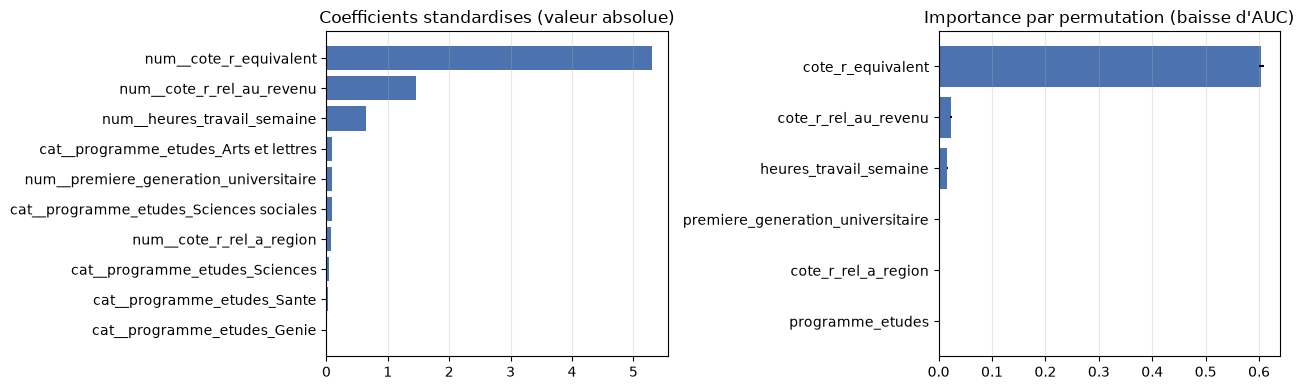

In [60]:
# Regression logistique : coefficients standardises, puis importance par permutation (baisse d'AUC).
coefs = coefficients(modele).rename('coefficient standardise')
print(coefs.round(3))
imp_perm = importance_permutation(modele, X_test, y_test)
print()
print(imp_perm.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tracer_importances(coefs.abs().sort_values(ascending=False), 'Coefficients standardises (valeur absolue)', ax=axes[0])
tracer_importances(imp_perm, 'Importance par permutation (baisse d\'AUC)', ax=axes[1])
plt.tight_layout()
plt.show()

### By slice

In [61]:
# Metriques par tranche contre la reference de merite (voir analyse_slices.ipynb pour le detail).
g_te = pd.Series(groupe_test, index=test.index, name='groupe')
bornes_revenu = np.quantile(train['revenu_familial_estime'], [0.2, 0.4, 0.6, 0.8])   # quintiles de train
tranches = {
    'region': test['region_administrative'].rename('region'),
    'cote R': pd.concat([pd.cut(test['cote_r_equivalent'], [0, 26, 27, 28, 29, 30, 32, 45]).astype(str)
                         .rename('cote R'), g_te], axis=1),
    'revenu': pd.concat([pd.cut(test['revenu_familial_estime'], np.r_[-np.inf, bornes_revenu, np.inf],
                                labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5']).astype(str).rename('revenu'), g_te], axis=1),
}
for nom, tranche in tranches.items():
    print(f'--- {nom} ---')
    print(tableau_tranches(y_test, y_pred, tranche, complet=True).round(3), end='\n\n')

--- region ---
                               effectif  meritants  taux_selection    tpr  \
region                                                                      
Bas-Saint-Laurent                 400.0      159.0           0.392  0.950   
Capitale-Nationale                611.0      282.0           0.460  0.940   
Cote-Nord                         364.0      152.0           0.426  0.934   
Gaspesie-Iles-de-la-Madeleine     461.0      202.0           0.427  0.950   
Montreal                         1164.0      524.0           0.444  0.943   

                                 fpr  precision  exactitude  
region                                                       
Bas-Saint-Laurent              0.025      0.962       0.965  
Capitale-Nationale             0.049      0.943       0.946  
Cote-Nord                      0.061      0.916       0.937  
Gaspesie-Iles-de-la-Madeleine  0.019      0.975       0.967  
Montreal                       0.036      0.956       0.954  

--- cote R

# Prediction

In [50]:
candidats = pd.read_csv('data/candidats_evaluation.csv')
groupe_cand = np.where(ajouter_eloignee(candidats)['eloignee'] == 1, 'Eloignee', 'Centre')
ajouter_attributs(candidats, reference=demandes)

# Modele final : modele de decision et cible sur tout l'historique, puis modele entraine sur cette cible.
modele_decision = ajuster_modele_decision(demandes)
modele_final = entrainer_modele_cible(demandes, cible_individuelle(modele_decision, demandes),
                                      new_features=NOUVELLES_VARIABLES)
X_cand = preparer(candidats)

In [69]:
# Meme seuil que le modele seul a l'entrainement (choisi sur train), ajuste dans le budget si besoin.
# proba_cand = modele_final.predict_proba(X_cand)[:, 1]

# Verification du taux avant d'ecrire : si le seuil sort du budget, on le deplace pour obtenir
# exactement la borne depassee (TAUX_MAX si trop d'octrois, TAUX_MIN si trop peu).
# seuil = seuil_modele
# taux = np.count_nonzero(proba_cand >= seuil) / len(proba_cand)
# if not TAUX_MIN <= taux <= TAUX_MAX:
#     borne = TAUX_MAX if taux > TAUX_MAX else TAUX_MIN
#     nb_octrois = int(np.floor(borne * len(proba_cand)))
#     seuil = np.sort(proba_cand)[::-1][nb_octrois - 1]   # plus petite probabilite encore accordee
#     print(f'Taux de {taux:.1%} hors budget avec le seuil {seuil_modele:.3f} : seuil ajuste a {seuil:.3f} '
#           f'pour {borne:.0%} d\'octroi')

# predictions = appliquer_seuil(proba_cand, seuil)
groupe_cand = np.where(ajouter_eloignee(candidats)['eloignee'] == 1, 'Eloignee', 'Centre')
predictions = postprocesseur.predict(X_cand, sensitive_features=groupe_cand, random_state=42)

soumission = pd.DataFrame({
    'id_candidat': candidats['id_candidat'],
    'decision_octroi': predictions.astype(int),
})
assert len(soumission) == 4000 and soumission['id_candidat'].is_unique
assert set(soumission['decision_octroi']) <= {0, 1}
taux = soumission['decision_octroi'].mean()
assert 0.36 <= taux <= 0.44, f'Hors budget : {taux:.1%}'
# assert TAUX_MIN <= taux <= TAUX_MAX

soumission.to_csv('predictions.csv', index=False)
print(f'{len(soumission)} lignes ecrites dans predictions.csv, taux d\'octroi {taux:.1%}')
print(soumission.groupby(groupe_cand)['decision_octroi'].mean().round(3).to_dict())

AssertionError: Hors budget : 44.3%